**Table of contents**<a id='toc0_'></a>    
- 1. [Meta analysis](#toc1_)    
- 2. [Import packages](#toc2_)    
- 3. [Read data](#toc3_)    
- 4. [Preprocess metadata](#toc4_)    
- 5. [Calculate alpha diversity metrics](#toc5_)    
- 6. [VAE](#toc6_)    
- 7. [Downstream tasks](#toc7_)    
  - 7.1. [Classification](#toc7_1_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# 1. <a id='toc1_'></a>[Meta analysis](#toc0_)

In [ ]:
#@save_meta_analysis
import importlib
from microbiome import ncbi, usearch_pipeline
[importlib.reload(package) for package in [ncbi, usearch_pipeline]]


# Download SRA data for project PRJNA1091851
def download_sra_data(project_id: str):
    sratool = ncbi.SRATools()  
    srr_ids, sequence_types = sratool.parse_meta(meta_file=f'../datas/meta_analysis/{project_id}.csv')
    # help(sratool)
    # help(sratool.download)
    # sratool.download(srr_ids=srr_ids[:1], sequence_types=sequence_types[:1], output_dir=f'../datas/meta_analysis/{project_id}')
 
    return srr_ids[:3], srr_ids.__len__()


def run_meta_pipeline(home_dir: str):
    # help(usearch_pipeline.UsearchPipeline)
    up = usearch_pipeline.UsearchPipeline(home_dir=home_dir)
    help(up.run)
    up.run()


# Run demo
download_sra_data(project_id='PRJNA978426')
run_meta_pipeline(home_dir='/bmp/backup/zhaosy/ws/china_16s_pipeline/results_demo')

2026-05-25 11:08:44.295 | INFO     | microbiome.usearch_pipeline:__init__:23 - Home directory set to /bmp/backup/zhaosy/ws/china_16s_pipeline/results_demo
2026-05-25 11:08:44.301 | INFO     | microbiome.usearch_pipeline:run:177 - Running the Usearch pipeline...
2026-05-25 11:08:44.305 | INFO     | microbiome.usearch_pipeline:show_files:44 - Data directory is set to: /bmp/backup/zhaosy/ws/china_16s_pipeline/results_demo/datas
2026-05-25 11:08:44.317 | INFO     | microbiome.usearch_pipeline:quality_control:50 - Quality control step starting...
2026-05-25 11:08:44.326 | INFO     | microbiome.usearch_pipeline:merge_paired_end_reads:62 - Merging paired-end reads...


Help on method run in module microbiome.usearch_pipeline:

run() method of microbiome.usearch_pipeline.UsearchPipeline instance
    One step to run all steps in the pipeline.
    Args:
        None
    Return:
        None
    Examples:
    >>> up = UsearchPipeline(home_dir='/path/to/home/dir')
    >>> up.run()

[Parallel(n_jobs=1)]: Done 1 out of 2 | elapsed:    2.9s


2026-05-25 11:08:52.336 | INFO     | microbiome.usearch_pipeline:merge_all_samples:73 - Merging all samples reads into one file...


[Parallel(n_jobs=1)]: Done 2 out of 2 | elapsed:    8.0s
[Parallel(n_jobs=1)]: Done 2 out of 2 | elapsed:    8.0s finished
Total reads in all samples:


2026-05-25 11:08:55.045 | INFO     | microbiome.usearch_pipeline:filter_low_quality_reads:83 - Filtering low-quality reads step starting...


...

Total unique reads after removing singletons:
33449


2026-05-25 11:09:16.976 | INFO     | microbiome.usearch_pipeline:denoise_to_zotus:131 - Denoising sequences to obtain zOTUs step starting...


Total OTUs after preorder:
1842


2026-05-25 11:09:18.276 | INFO     | microbiome.usearch_pipeline:build_zotu_feature_table:156 - Building the zOTU feature table step starting...


Total ZOTUs after denoising:
1829


# 2. <a id='toc2_'></a>[Import packages](#toc0_)

In [6]:
#@save Basic packages
import importlib
from loguru import logger
from pathlib import Path
from tqdm import tqdm

# Scientific computing
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
sns.set_theme(
    context='paper', style='ticks', palette='husl', font='arial',
    rc={
        'svg.fonttype': 'none',
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'axes.titlesize': 8,
        'axes.labelsize': 8,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,
        }
)

# machine learning
import sklearn
import torch 

# Microbiome analysis
from microbiome import amplicon
importlib.reload(amplicon)

<module 'microbiome.amplicon' from '/bmp/backup/zhaosy/ws/china_16s_pipeline/src/microbiome/amplicon.py'>

In [7]:
#@save Set up workspace directory

# home_dir: Path = Path().cwd().parent
home_dir: Path = Path('/bmp/backup/zhaosy/ws/china_16s_pipeline')    
logger.info(f'Home directory: {home_dir}')
    
ws_dir: Path = home_dir.joinpath('results/models')
logger.info(f'Workspace directory: {ws_dir}')

2026-04-08 14:15:58.357 | INFO     | __main__:<module>:5 - Home directory: /bmp/backup/zhaosy/ws/china_16s_pipeline
2026-04-08 14:15:58.359 | INFO     | __main__:<module>:8 - Workspace directory: /bmp/backup/zhaosy/ws/china_16s_pipeline/results/models


# 3. <a id='toc3_'></a>[Read data](#toc0_)

In [8]:
#@save
# Get feature tables.
logger.info('Parsing feature tables...')
feature_dir: Path = home_dir.joinpath('results', 'feature_table_from_Jiahe')
metainfo_path: Path = home_dir.joinpath('datas', 'metadata.xlsx')


amplicon_operator = amplicon.Amplicon(
    otu_file_path=feature_dir.joinpath('asvtab.txt'),
    sintax_file_path=feature_dir.joinpath('asv.sintax'),
    metadata_file_path=metainfo_path
)
otu_table, taxonomy_table, metadata_table = amplicon_operator.features_parser()

otu_table.shape, taxonomy_table.shape, metadata_table.shape

2026-04-08 14:16:24.105 | INFO     | __main__:<module>:3 - Parsing feature tables...


((178091, 3910), (178091, 8), (3916, 49))

# 4. <a id='toc4_'></a>[Preprocess metadata](#toc0_)

In [9]:
#@save
# disease_variables = ['EarlyBlight', 'LateBlight', 'CommonScab', 'BlackScurf', 'PowderyScab', 'BactericalWilt', 'BlackLeg', 'Wilt', 'Virus', 'DiseaseMumber'] # Host association disease information
disease_variables = ['EarlyBlight', 'LateBlight', 'CommonScab', 'BlackScurf', 'PowderyScab', 'BactericalWilt', 'BlackLeg', 'Wilt', 'Virus'] # Host association disease information
variables = [
    'Batch', 
    'Group', 'Code', 
    'Longitude', 'Latitude', 'Altitude', 'Elevation',                                   # Geographic factors
    'AreaName', 'Area', 'Loacation', 'City',                                            # Geographic factors
    'Temperature', 'Precipitation',                                                     # Environmental climatic factors
    'Soil', 'Soil_pH',                                                                  # Environmental soil properties
    'Breeding', 'PreviousCrop', 'Mode', 'Scale',                                        # management practices
    'PartName', 'Part',                                                                 # Host association
    # 'EarlyBlight', 'LateBlight', 'CommonScab', 'BlackScurf', 'PowderyScab', 'BactericalWilt', 'BlackLeg', 'Wilt', 'Virus', 'DiseaseMumber'
] + disease_variables

variables.__len__()

30

In [10]:
#@save
# metadata_table[variables]
df = metadata_table[disease_variables].replace({'Unclear': np.nan})
df = df.dropna()

df.shape

(3170, 9)

In [11]:
#@save
df['Status'] = df.apply(lambda row: 'Healthy' if row[disease_variables].sum() == 0 else 'Diseased', axis=1)

In [12]:
df['Status'].value_counts()

Status
Diseased    2717
Healthy      453
Name: count, dtype: int64

In [13]:
df

,EarlyBlight,LateBlight,CommonScab,BlackScurf,PowderyScab,BactericalWilt,BlackLeg,Wilt,Virus,Status
SampleID,,,,,,,,,,
G1a,3,0,0,0,0,0,0,0,0,Diseased
G1b,3,0,0,0,0,0,0,0,0,Diseased
G1c,3,0,0,0,0,0,0,0,0,Diseased
G1d,3,0,0,0,0,0,0,0,0,Diseased
G1e,3,0,0,0,0,0,0,0,0,Diseased
...,...,...,...,...,...,...,...,...,...,...
F404a,0,0,2,0,0,1,0,3,0,Diseased
F404b,0,0,2,0,0,1,0,3,0,Diseased
F404c,0,0,2,0,0,1,0,3,0,Diseased


# 5. <a id='toc5_'></a>[Calculate alpha diversity metrics](#toc0_)

In [ ]:
rared_otu_table: pd.DataFrame = pd.read_csv(ws_dir.joinpath('asvtab_raw_rare_4k.txt'), index_col=0, sep='\t')
rared_otu_table.index.name = "OTU_ID"

print(rared_otu_table.shape)
rared_otu_table.head(3)

In [96]:
alpha_metrics: list[str] = [
    'shannon', 'simpson_d',             # diversity
    'observed_features', 'chao1',       # richness
    'pielou_e', 'simpson_e',            # evenness
    'gini_index',                       # 优势物种
    'goods_coverage',                   # coverage
]

alpha_metrics_df_dict: dict[str, pd.Series] = {}

for metric in tqdm(alpha_metrics, desc='Calculating alpha diversity metrics'):
    metric_series: pd.Series = skbio.diversity.alpha_diversity(
        metric=metric,
        counts=rared_otu_table.values.T,    # Sample_id as index
        ids=rared_otu_table.T.index,        # Sample_id as index
    )
    alpha_metrics_df_dict[metric] = metric_series
    
alpha_metrics_df = pd.DataFrame(alpha_metrics_df_dict)
alpha_metrics_df.index.name = 'SampleID'

Calculating alpha diversity metrics: 100%|██████████| 8/8 [00:26<00:00,  3.35s/it]


In [100]:
# alpha_metrics_df[alpha_metrics] = sklearn.preprocessing.StandardScaler().fit_transform(alpha_metrics_df[alpha_metrics])
alpha_metrics_df[alpha_metrics] = sklearn.preprocessing.MinMaxScaler().fit_transform(alpha_metrics_df[alpha_metrics])
alpha_metrics_df = pd.DataFrame(alpha_metrics_df, index=rared_otu_table.T.index, columns=alpha_metrics)
alpha_metrics_df.index.name = 'SampleID'
alpha_metrics_df

,shannon,simpson_d,observed_features,chao1,pielou_e,simpson_e,gini_index,goods_coverage
SampleID,,,,,,,,
F100a,0.919036,0.011632,0.815500,0.605294,0.941495,0.637207,0.273907,0.269942
F100b,0.939304,0.008665,0.860346,0.693999,0.955590,0.688019,0.211584,0.206712
F100c,0.941797,0.007413,0.869394,0.741617,0.955941,0.722130,0.203204,0.180934
F100d,0.927189,0.011240,0.838710,0.645602,0.944912,0.630757,0.243045,0.236381
F100e,0.941038,0.009616,0.868214,0.687418,0.955192,0.654068,0.200333,0.198444
...,...,...,...,...,...,...,...,...
G9a,0.749485,0.099980,0.649882,0.582030,0.738827,0.153444,0.521458,0.389105
G9b,0.756490,0.094707,0.651062,0.530200,0.749925,0.162141,0.515631,0.403696
G9c,0.764303,0.084678,0.647915,0.504195,0.764554,0.182758,0.516138,0.415856


In [149]:
alpha_metrics_metadata_df: pd.DataFrame = alpha_metrics_df.merge(right=metadata_table, left_index=True, right_index=True, how='left')
alpha_metrics_metadata_df.head(3)

,shannon,simpson_d,observed_features,chao1,pielou_e,simpson_e,gini_index,goods_coverage,Group,Code,...,Disease,早疫病,晚疫病,疮痂病,黑痣病,粉痂病,青枯病,黑胫病,枯萎病,病毒病
SampleID,,,,,,,,,,,,,,,,,,,,,
F100a,0.919036,0.011632,0.815500,0.605294,0.941495,0.637207,0.273907,0.269942,F100,100,...,中重度晚疫病,0,4,0,0,0,0,0,0,0
F100b,0.939304,0.008665,0.860346,0.693999,0.955590,0.688019,0.211584,0.206712,F100,100,...,中重度晚疫病,0,4,0,0,0,0,0,0,0
F100c,0.941797,0.007413,0.869394,0.741617,0.955941,0.722130,0.203204,0.180934,F100,100,...,中重度晚疫病,0,4,0,0,0,0,0,0,0


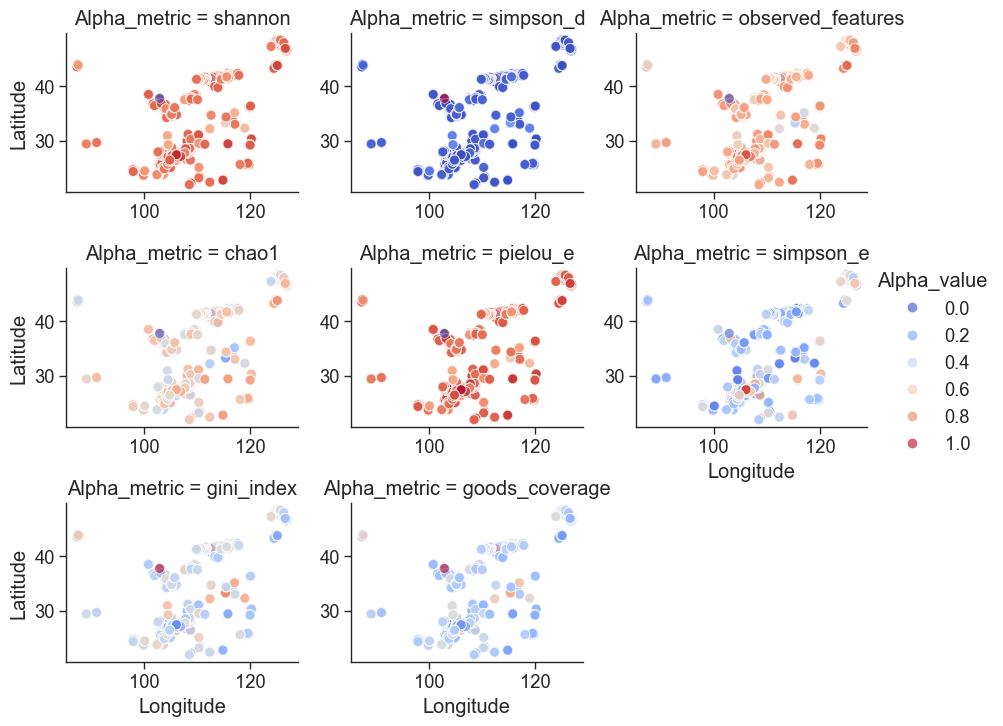

In [ ]:
sns.relplot(
    data=alpha_metrics_metadata_df.melt(id_vars=['Longitude', 'Latitude', 'Elevation'], value_vars=alpha_metrics, var_name='Alpha_metric', value_name='Alpha_value'), 
    x='Longitude', y='Latitude', hue='Alpha_value', palette='coolwarm', s=50, alpha=0.6,
    col='Alpha_metric', col_wrap=3, height=2.5, aspect=1.2,
    kind='scatter',
    facet_kws={'sharex': False, 'sharey': False}
)
# sns.despine()

# 6. <a id='toc6_'></a>[VAE](#toc0_)

2026-02-25 10:50:07.854 | INFO     | microbiome.amplicon:filter_otu_table_by_sample:274 - Sample total abundance filtering thresholds: min=3961.4, max=75284.5
2026-02-25 10:50:07.884 | INFO     | microbiome.amplicon:filter_otu_table_by_sample:279 - Raw/Filtered shape: (178091, 3910) -> (178091, 3376), kept samples: 86.34%


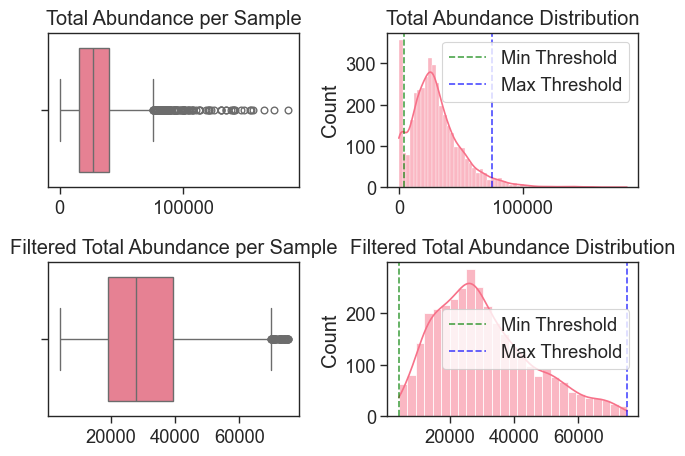

2026-02-25 10:50:23.663 | INFO     | microbiome.amplicon:filter_otu_table_by_otu:340 - Raw/Filtered shape: (178091, 3376) -> (75402, 3376), kept samples: 42.34%


(75402, 3376)

In [9]:
#@save
filtered_otu_table = microbiome.amplicon.OTUQC.filter_otu_table_by_sample(otu_table_df=otu_table, method='abundance', min_max_threshold=(3961.4, 75284.5))
filtered_otu_table = microbiome.amplicon.OTUQC.filter_otu_table_by_otu(otu_table_df=filtered_otu_table, min_prevalence=0.01, min_abundance=0.000001, show=False)
filtered_otu_table.shape

In [10]:
#@save vae model
from microbiome import vae 
importlib.reload(vae)


vae_pipeline = vae.VAEPipeline(seed=123)

2026-02-25 10:50:23.681 | INFO     | microbiome.vae:__init__:122 - Reproducibility: Setting random seed to 123 for torch, numpy, and random.


In [11]:
#@save
clr_otu_table = vae_pipeline.preprocess(otu_table=filtered_otu_table)
clr_otu_table.head(3)

2026-02-25 10:50:23.723 | INFO     | microbiome.vae:preprocess:138 - Adding pseudocount and CLR transformation to OTU table...


2026-02-25 10:50:31.784 | INFO     | microbiome.vae:preprocess:147 - Scale [SKLEARN StandardScaler] CLR-transformed OTU table...


OTU_ID,Zotu1,Zotu10,Zotu100,Zotu1000,Zotu10000,Zotu10001,Zotu100013,Zotu10002,Zotu100020,Zotu10003,...,Zotu9993,Zotu99933,Zotu9994,Zotu9995,Zotu9996,Zotu99964,Zotu9997,Zotu99975,Zotu9998,Zotu9999
SampleID,,,,,,,,,,,,,,,,,,,,,
F100a,-0.043492,-1.206220,-1.349474,0.872902,-0.276582,-0.390264,2.106954,-0.392021,-0.139419,-0.330470,...,-0.365509,-0.077936,-0.285443,-0.371423,-0.402483,-0.164773,-0.440417,-0.060283,-0.506675,-0.418024
F100b,0.075505,-1.211655,-1.355952,1.039832,-0.288581,-0.400097,2.087065,-0.401610,-0.159121,-0.341279,...,-0.375711,-0.102834,-0.296919,-0.381680,-0.412071,-0.183010,2.317360,-0.086764,-0.515163,-0.427405
F100c,-1.194479,-1.296840,0.453885,0.777793,-0.476660,-0.554223,1.734571,-0.551905,-0.467931,-0.510716,...,-0.535617,-0.493100,-0.476790,-0.542458,-0.562358,-0.468872,2.042446,-0.501831,-0.648208,-0.574430


In [12]:
#@save vae model
import torch 


model_configs = {
    # 'latent_dim': 4,
    # 'latent_dim': 8,
    'latent_dim': 16,
    # 'latent_dim': 32,
    # 'latent_dim': 128,

    # 'beta': 1.0,
    # 'beta': 0.01,
    'beta': 0.001,
}
# model, metric_df = vae_pipeline.fit(
#     model_configs=model_configs, 
#     otu_table=clr_otu_table, 
#     device='cuda:1', epochs=1, batch_size=16, lr=1e-3,
#     ckpt_dir= ws_dir.joinpath('checkpoints_001'),
# )
# metric_df.to_csv(ws_dir.joinpath('vae_training_metrics.csv'))

# Laoding
model = vae.VAE(
    input_dim=clr_otu_table.shape[1],
    latent_dim=model_configs['latent_dim'],
)
model.load_state_dict(
    torch.load(
        ws_dir.joinpath('checkpoints_002', 'vae_epoch_1000.pth'),
        map_location={'cuda:1': 'cuda:0'}
    )
)
metric_df = pd.read_csv(ws_dir.joinpath('vae_training_metrics.csv'), index_col=0)
metric_df.head(3)

,Epoch,Train Loss,Recon Loss,KL Loss,Learning Rate
0,1,0.921013,0.919243,1.769873,0.001
1,2,0.869450,0.867094,2.355654,0.001
2,3,0.842321,0.839686,2.635519,0.001


In [ ]:
# from deepspore.ipynb import ipynb2


# ipynb2(
#     ipynb_file='006_pipeline_models.ipynb',
#     label='#@save',
#     output_file='006_pipeline_models.py',
# )

Saved 10 block(s) to 006_pipeline_models.py


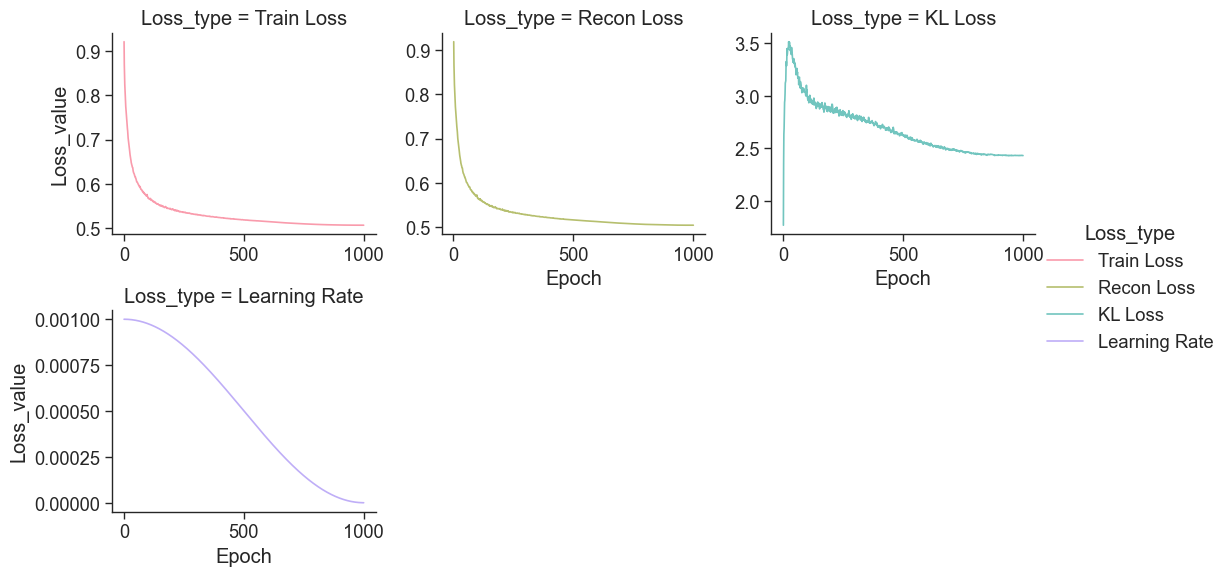

In [13]:
sns.relplot(
    data=metric_df.melt(id_vars=['Epoch'], value_vars=['Train Loss', 'Recon Loss', 'KL Loss', 'Learning Rate'], var_name='Loss_type', value_name='Loss_value'), 
    x='Epoch', y='Loss_value', 
    hue='Loss_type', palette='husl', alpha=0.7,
    kind='line',
    facet_kws={'sharex': False, 'sharey': False},
    height=3, aspect=1.2,
    col='Loss_type', col_wrap=3
)

In [45]:
latent_df = vae_pipeline.get_latent_representation(
    model=model, 
    otu_table=clr_otu_table, 
    device='cuda:0',
)
print(f'latent_df shape: {latent_df.shape}')
latent_df.head(3)

/bmp/backup/zhaosy/miniconda3/envs/china/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


latent_df shape: (3376, 22)


,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,UMAP1,UMAP2,TSNE1,TSNE2,PCA1,PCA2
SampleID,,,,,,,,,,,,,,,,,,,,,
F100a,-0.824150,-1.301001,-0.277622,-0.737350,-0.427503,0.516209,-1.638446,-1.367332,-2.008444,1.082555,...,0.060645,-0.235185,-0.859014,-1.103463,11.073817,2.751619,-52.927013,-31.780851,-1.320803,-0.398525
F100b,-0.775346,-1.185619,0.067668,-0.958365,-0.483286,0.587390,-1.789358,-1.612311,-1.932081,1.177135,...,0.050482,-0.131145,-1.018679,-1.058605,11.021467,2.740478,-52.946552,-31.926859,-1.541306,-0.514594
F100c,-1.973667,-2.918745,1.373109,0.476463,0.864615,1.206738,-3.508301,-1.877621,0.056241,1.012823,...,-0.184333,-1.881401,-0.918474,-0.612751,11.479116,5.071788,28.207691,-42.485928,-2.412405,1.381634


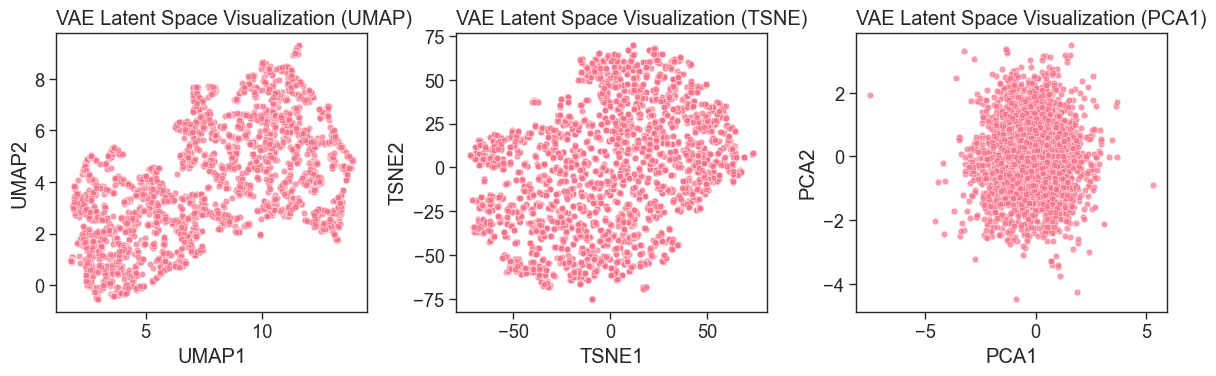

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (x, y) in enumerate([('UMAP1', 'UMAP2'), ('TSNE1', 'TSNE2'), ('PCA1', 'PCA2')]):
    sns.scatterplot(
        ax=axes[i],
        data=latent_df,
        x=x, y=y, alpha=0.7,
    )
    axes[i].set_title(f'VAE Latent Space Visualization ({x[:4]})', loc='left')
fig.tight_layout()

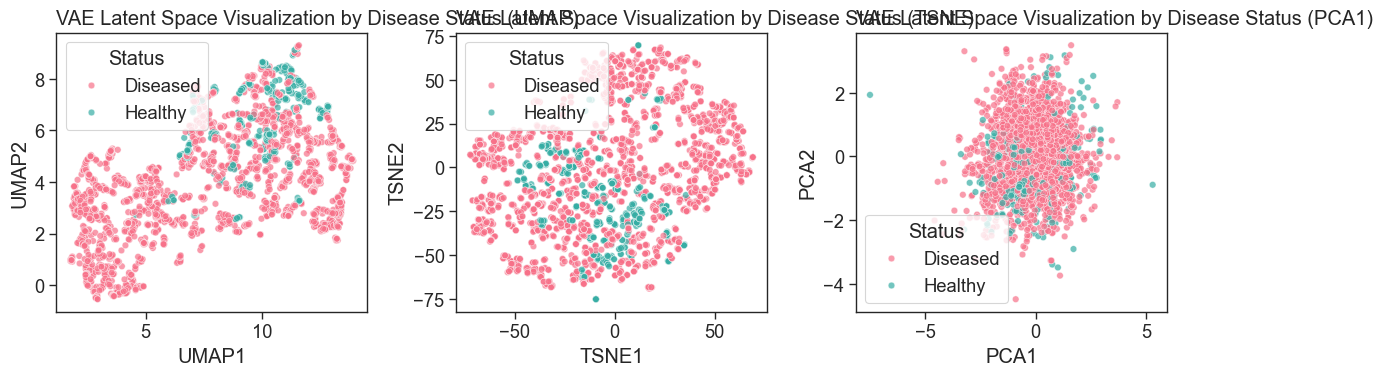

In [63]:
temp_df = df.merge(right=latent_df, left_index=True, right_index=True, how='left')
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (x, y) in enumerate([('UMAP1', 'UMAP2'), ('TSNE1', 'TSNE2'), ('PCA1', 'PCA2')]):
    sns.scatterplot(
        ax=axes[i],
        data=temp_df,
        x=x, y=y, hue='Status', palette='husl', alpha=0.7,
    )
    axes[i].set_title(f'VAE Latent Space Visualization by Disease Status ({x[:4]})', loc='left')
fig.tight_layout()

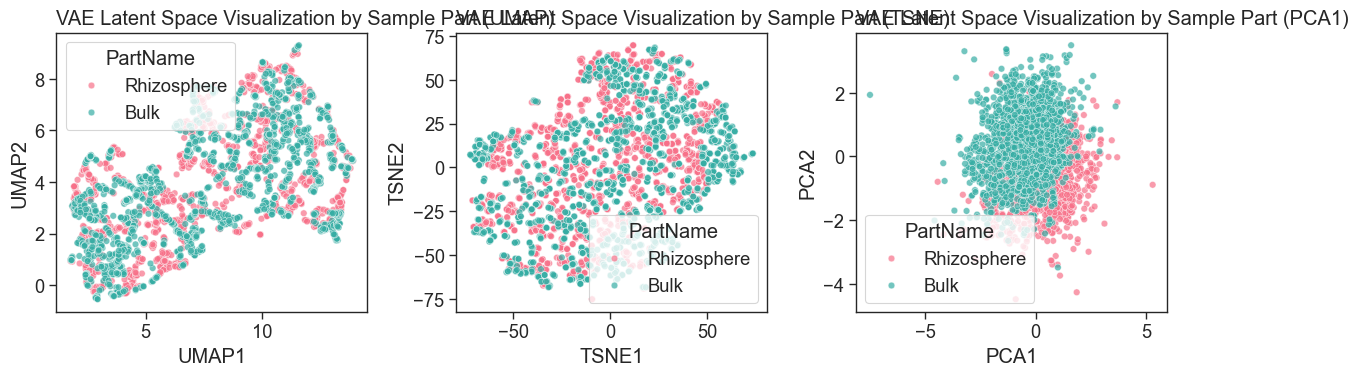

In [71]:
temp_df = metadata_table.merge(right=latent_df, left_index=True, right_index=True, how='left')
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (x, y) in enumerate([('UMAP1', 'UMAP2'), ('TSNE1', 'TSNE2'), ('PCA1', 'PCA2')]):
    sns.scatterplot(
        ax=axes[i],
        data=temp_df,
        x=x, y=y, hue='PartName', palette='husl', alpha=0.7,
    )
    axes[i].set_title(f'VAE Latent Space Visualization by Sample Part ({x[:4]})', loc='left')
fig.tight_layout()

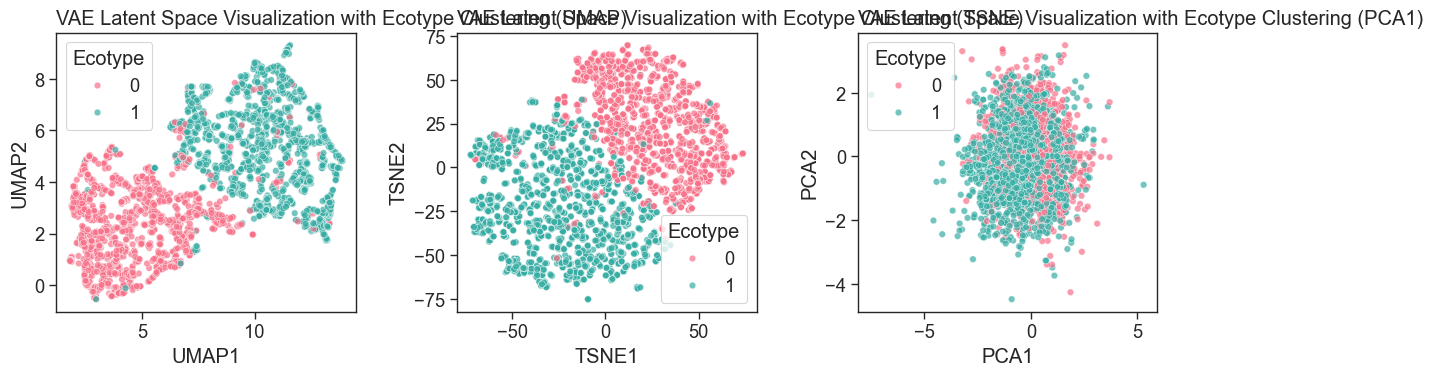

In [77]:
latent_clustered_df = vae_pipeline.ecotype_clustering(
    latent_df=latent_df.copy(), 
    # method='kmeans', n_clusters=2,
    method='gauss', n_clusters=2,
)
# latent_clustered_df.head(3)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (x, y) in enumerate([('UMAP1', 'UMAP2'), ('TSNE1', 'TSNE2'), ('PCA1', 'PCA2')]):
    sns.scatterplot(
        ax=axes[i],
        data=latent_clustered_df,
        x=x, y=y, hue='Ecotype', palette='husl', alpha=0.7,
    )
    axes[i].set_title(f'VAE Latent Space Visualization with Ecotype Clustering ({x[:4]})', loc='left')
fig.tight_layout()

# 7. <a id='toc7_'></a>[Downstream tasks](#toc0_)

## 7.1. <a id='toc7_1_'></a>[Classification](#toc0_)

In [103]:
from microbiome import vae
importlib.reload(vae)


temp_df1 = df[['Status']].merge(right=latent_df.iloc[:, :16], left_index=True, right_index=True, how='inner')
print(f'temp_df1 shape: {temp_df1.shape}')
temp_df1.head(3)
metrics_df1 = vae.DownstreamTasks.classification(
    latent_df=temp_df1.drop(columns=['Status']),
    labels=temp_df1['Status'],
    models=['rf', 'lr', 'svm'],
    verbose=False,
)
# metrics_df1


temp_df1 shape: (2768, 17)

Overall Classification Metrics:
         kfold  accuracy  precision    recall        f1
mean  5.500000  0.915823   0.907346  0.915823  0.902832
std   2.921384  0.044485   0.059030  0.044485  0.056351


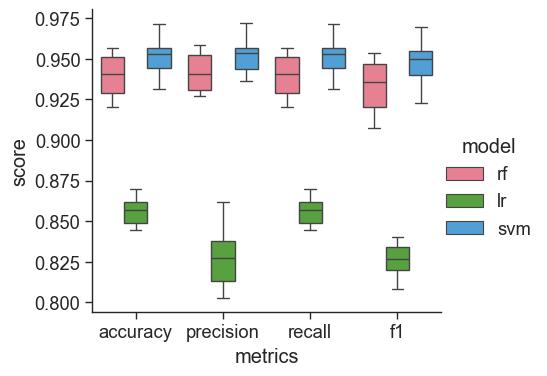

In [108]:
sns.catplot(
    kind='box',
    data=metrics_df1.melt(id_vars=['model', 'kfold'], value_vars=['accuracy', 'precision', 'recall', 'f1'], var_name='metrics', value_name='score'),
    x='metrics', y='score', hue='model', palette='husl',
    height=4, aspect=1.2,
)

In [109]:
temp_df2 = filtered_otu_table.T.merge(right=df[['Status']], left_index=True, right_index=True, how='inner')
print(f'temp_df2 shape: {temp_df2.shape}')
temp_df2.head(3)
metrics_df2 = vae.DownstreamTasks.classification(
    latent_df=temp_df2.drop(columns=['Status']),
    labels=temp_df2['Status'],
    models=['rf', 'lr'],
    verbose=True,
)
# metrics_df2

temp_df2 shape: (2768, 75403)
K-Fold 1, Model: rf:
Accuracy: 0.9603, Precision: 0.9621, Recall: 0.9603, F1 Score: 0.9577
K-Fold 1, Model: lr:
Accuracy: 0.9964, Precision: 0.9964, Recall: 0.9964, F1 Score: 0.9964
K-Fold 2, Model: rf:
Accuracy: 0.9567, Precision: 0.9588, Recall: 0.9567, F1 Score: 0.9535
K-Fold 2, Model: lr:
Accuracy: 0.9928, Precision: 0.9931, Recall: 0.9928, F1 Score: 0.9929
K-Fold 3, Model: rf:
Accuracy: 0.9531, Precision: 0.9517, Recall: 0.9531, F1 Score: 0.9518
K-Fold 3, Model: lr:
Accuracy: 0.9819, Precision: 0.9829, Recall: 0.9819, F1 Score: 0.9822
K-Fold 4, Model: rf:
Accuracy: 0.9350, Precision: 0.9367, Recall: 0.9350, F1 Score: 0.9284
K-Fold 4, Model: lr:
Accuracy: 0.9819, Precision: 0.9818, Recall: 0.9819, F1 Score: 0.9819
K-Fold 5, Model: rf:
Accuracy: 0.9711, Precision: 0.9711, Recall: 0.9711, F1 Score: 0.9702
K-Fold 5, Model: lr:
Accuracy: 0.9928, Precision: 0.9928, Recall: 0.9928, F1 Score: 0.9928
K-Fold 6, Model: rf:
Accuracy: 0.9422, Precision: 0.9435, Re

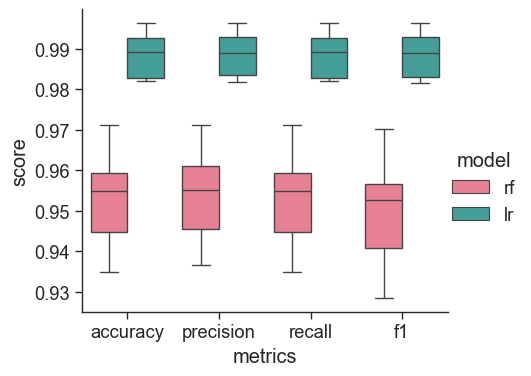

In [110]:
sns.catplot(
    kind='box',
    data=metrics_df2.melt(id_vars=['model', 'kfold'], value_vars=['accuracy', 'precision', 'recall', 'f1'], var_name='metrics', value_name='score'),
    x='metrics', y='score', hue='model', palette='husl',
    height=4, aspect=1.2,
)

In [ ]:
# filtered_otu_table
from sklearn.decomposition import PCA


clf = PCA()
pca_filtered_otu_table = clf.fit_transform(filtered_otu_table.T)

In [29]:
pca_filtered_otu_table = pd.DataFrame(pca_filtered_otu_table, index=filtered_otu_table.T.index, columns=[f'PCA{i+1}' for i in range(pca_filtered_otu_table.shape[1])])
pca_filtered_otu_table.head(3)

,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9,PCA10,...,PCA3367,PCA3368,PCA3369,PCA3370,PCA3371,PCA3372,PCA3373,PCA3374,PCA3375,PCA3376
SampleID,,,,,,,,,,,,,,,,,,,,,
F100a,-447.089617,-95.231831,-1.272593,-74.648249,-239.458692,-61.703008,122.495980,-66.457403,0.499610,53.349273,...,-0.010389,0.290429,-0.006295,0.310304,-0.236673,0.096960,0.366391,-0.065198,0.100216,-7.033105e-14
F100b,-421.398486,-69.406189,-10.018937,-78.850655,-239.193678,-53.536614,117.239111,-69.527859,-5.027315,56.493340,...,-0.080822,-0.028976,0.133356,-0.121492,0.466852,-0.010886,-0.173499,0.074697,-0.159952,-7.033105e-14
F100c,-350.422170,38.312256,-29.948715,53.563094,-144.999458,233.324407,211.572615,202.035512,-121.897862,149.581999,...,-0.052577,-0.044027,0.101088,0.083714,0.032944,-0.025466,0.098601,0.049072,0.055598,-7.033105e-14


In [31]:
temp_pca_df = df[['Status']].merge(right=pca_filtered_otu_table.iloc[:, :], left_index=True, right_index=True, how='inner')

/bmp/backup/zhaosy/miniconda3/envs/china/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/bmp/backup/zhaosy/miniconda3/envs/china/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


/bmp/backup/zhaosy/miniconda3/envs/china/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/bmp/backup/zhaosy/miniconda3/envs/china/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/bmp/backup/zhaosy/miniconda3/envs/china/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod


Overall Classification Metrics:
         kfold  accuracy  precision    recall        f1
mean  5.500000  0.842969   0.738580  0.842969  0.784414
std   2.921384  0.012768   0.027739  0.012768  0.010310


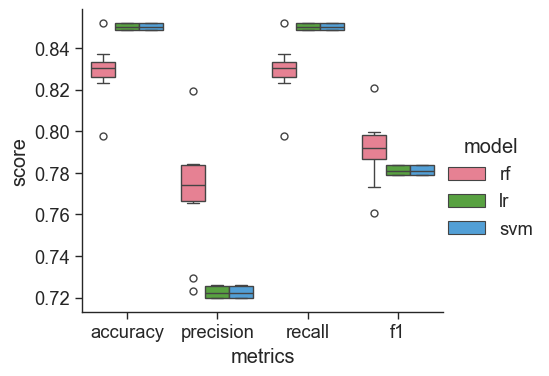

In [42]:
metrics_df4 = vae.DownstreamTasks.classification(
    latent_df=temp_pca_df.iloc[:, 0:3].drop(columns=['Status']),
    labels=temp_pca_df['Status'],
    models=['rf', 'lr', 'svm'],
    verbose=False,
)
sns.catplot(
    kind='box',
    data=metrics_df4.melt(id_vars=['model', 'kfold'], value_vars=['accuracy', 'precision', 'recall', 'f1'], var_name='metrics', value_name='score'),
    x='metrics', y='score', hue='model', palette='husl',
    height=4, aspect=1.2,
)

In [ ]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# logreg = LogisticRegression()
# length = 100
# logreg.fit(temp_pca_df.iloc[:, 1:length], temp_pca_df['Status'])

# y_pred = logreg.predict(temp_pca_df.iloc[:, 1:length])
# accuracy = accuracy_score(temp_pca_df['Status'], y_pred)
# precision = precision_score(temp_pca_df['Status'], y_pred, average='weighted')
# recall = recall_score(temp_pca_df['Status'], y_pred, average='weighted')
# f1 = f1_score(temp_pca_df['Status'], y_pred, average='weighted')

# print(f'Accuracy: {accuracy:.4f}')
# print(f'Precision: {precision:.4f}')
# print(f'Recall: {recall:.4f}')
# print(f'F1 Score: {f1:.4f}')

Accuracy: 0.8540
Precision: 0.8600
Recall: 0.8540
F1 Score: 0.8568


/bmp/backup/zhaosy/miniconda3/envs/china/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/bmp/backup/zhaosy/miniconda3/envs/china/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/bmp/backup/zhaosy/miniconda3/envs/china/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/bmp/backup/zhaosy/miniconda3/envs/china/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod


Overall Classification Metrics:
         kfold  accuracy  precision    recall        f1
mean  5.500000  0.842127   0.734661  0.842127  0.781954
std   2.921384  0.013586   0.020870  0.013586  0.005504


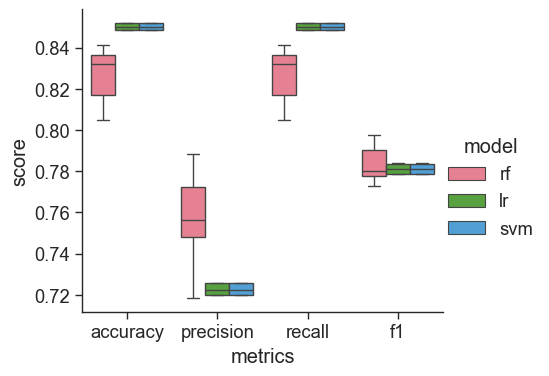

In [24]:
temp_df3 = latent_df[['PCA1', 'PCA2']].merge(right=df[['Status']], left_index=True, right_index=True, how='inner')
metrics_df3 = vae.DownstreamTasks.classification(
    latent_df=temp_df3.drop(columns=['Status']),
    labels=temp_df3['Status'],
    models=['rf', 'lr', 'svm'],
    verbose=False,
)
sns.catplot(
    kind='box',
    data=metrics_df3.melt(id_vars=['model', 'kfold'], value_vars=['accuracy', 'precision', 'recall', 'f1'], var_name='metrics', value_name='score'),
    x='metrics', y='score', hue='model', palette='husl',
    height=4, aspect=1.2,
)

# 